In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
walking = pd.read_csv("walking.csv")
sleeping = pd.read_csv("sleeping.csv")

print("Walking:", walking.shape)
print("Sleeping:", sleeping.shape)

walking.head()

Walking: (368, 64)
Sleeping: (4251, 64)
Walking: (368, 64)
Sleeping: (4251, 64)
label
1    368
0    368
Name: count, dtype: int64
(736, 18)
ax_mean    0
ax_std     0
ax_rms     0
ax_ptp     0
ay_mean    0
ay_std     0
ay_rms     0
ay_ptp     0
az_mean    0
az_std     0
az_rms     0
az_ptp     0
gx_std     0
gx_rms     0
gy_std     0
gy_rms     0
gz_std     0
gz_rms     0
dtype: int64


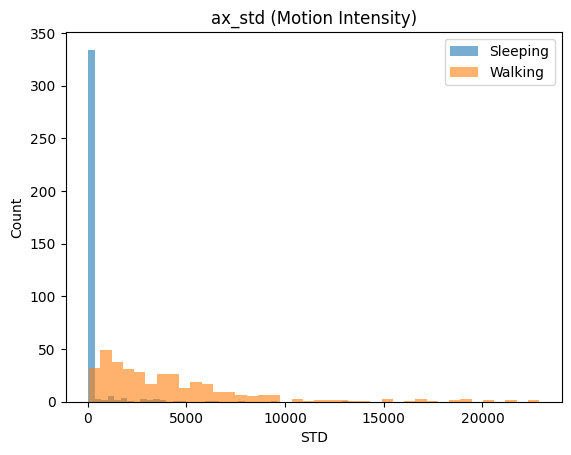

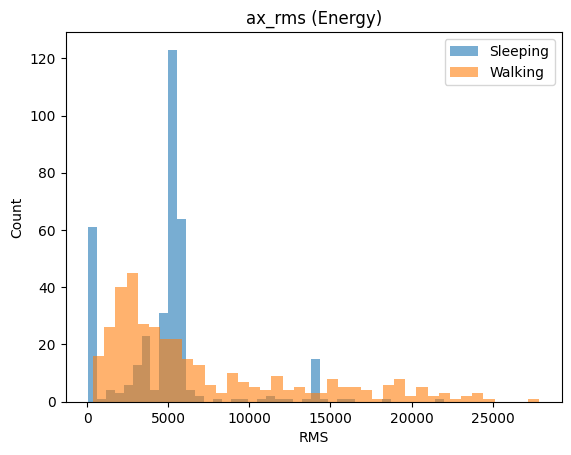

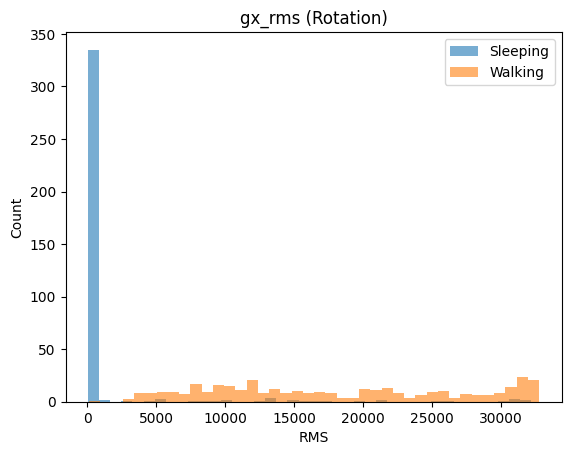

/tmp/ipykernel_15511/1471534746.py:112: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


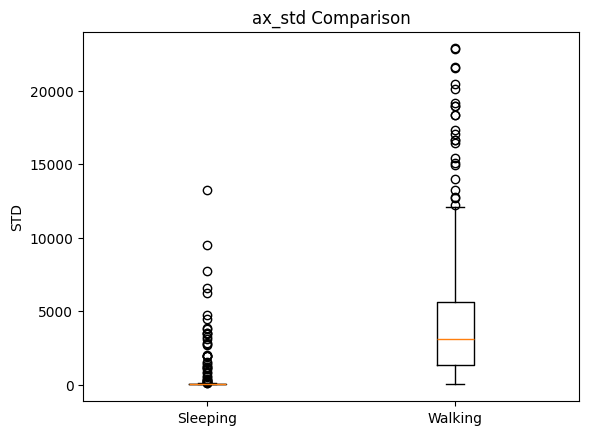

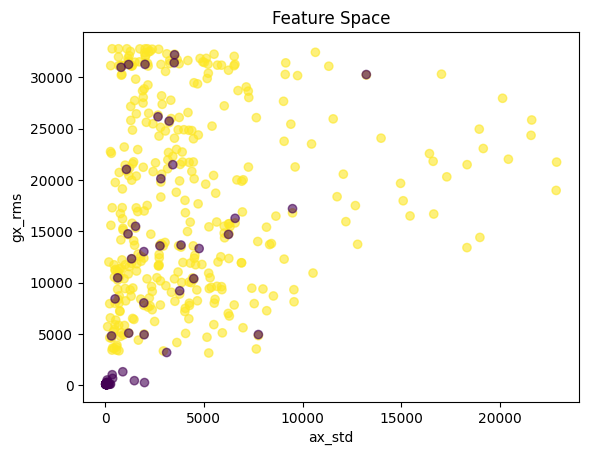

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       1.00      0.93      0.97        74
           1       0.94      1.00      0.97        74

    accuracy                           0.97       148
   macro avg       0.97      0.97      0.97       148
weighted avg       0.97      0.97      0.97       148

[[69  5]
 [ 0 74]]


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458 (1.79 KB)

 Trainable params: 458 (1.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7383 - loss: 0.5468 - val_accuracy: 0.8644 - val_loss: 0.3391
Epoch 2/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8915 - loss: 0.2903 - val_accuracy: 0.8814 - val_loss: 0.2773
Epoch 3/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9234 - loss: 0.2292 - val_accuracy: 0.9068 - val_loss: 0.2599
Epoch 4/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9404 - loss: 0.2046 - val_accuracy: 0.9068 - val_loss: 0.2546
Epoch 5/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9468 - loss: 0.1916 - val_accuracy: 0.9153 - val_loss: 0.2467
Epoch 6/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9511 - loss: 0.1808 - val_accuracy: 0.9237 - val_loss: 0.2453
Epoch 7/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9553 - loss: 0.1737 - val_accuracy: 0.9237 - val_loss: 0.2446
Epoch 8/40
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9596 - loss: 0.1675 - val_accuracy: 0.9322 - val_loss:

In [4]:
walking = pd.read_csv("walking.csv")
sleeping = pd.read_csv("sleeping.csv")

print("Walking:", walking.shape)
print("Sleeping:", sleeping.shape)

walking.head()


walking = walking.drop(columns=["time"])
sleeping = sleeping.drop(columns=["time"])

walking["label"]  = 1   # walking
sleeping["label"] = 0   # sleeping


sleeping_balanced = sleeping.sample(
    n=len(walking),
    random_state=42
)

data = pd.concat([walking, sleeping_balanced], ignore_index=True)
data = data.select_dtypes(include=[np.number])

print(data["label"].value_counts())


y = data["label"]
X_raw = data.drop(columns=["label"])

X_raw = X_raw.apply(pd.to_numeric, errors="coerce")


def build_stat_features(df):
    feats = {}

    for axis in ["ax", "ay", "az"]:
        vals = df[[f"{axis}{i}" for i in range(10)]].values
        feats[f"{axis}_mean"] = np.nanmean(vals, axis=1)
        feats[f"{axis}_std"]  = np.nanstd(vals, axis=1)
        feats[f"{axis}_rms"]  = np.sqrt(np.nanmean(vals**2, axis=1))
        feats[f"{axis}_ptp"]  = np.nanmax(vals, axis=1) - np.nanmin(vals, axis=1)

    for axis in ["gx", "gy", "gz"]:
        vals = df[[f"{axis}{i}" for i in range(10)]].values
        feats[f"{axis}_std"] = np.nanstd(vals, axis=1)
        feats[f"{axis}_rms"] = np.sqrt(np.nanmean(vals**2, axis=1))

    return pd.DataFrame(feats)


X = build_stat_features(X_raw)

print(X.shape)
print(X.isna().sum())


plt.figure()
plt.hist(X[y==0]["ax_std"], bins=40, alpha=0.6, label="Sleeping")
plt.hist(X[y==1]["ax_std"], bins=40, alpha=0.6, label="Walking")
plt.legend()
plt.title("ax_std (Motion Intensity)")
plt.xlabel("STD")
plt.ylabel("Count")
plt.show()


plt.figure()
plt.hist(X[y==0]["ax_rms"], bins=40, alpha=0.6, label="Sleeping")
plt.hist(X[y==1]["ax_rms"], bins=40, alpha=0.6, label="Walking")
plt.legend()
plt.title("ax_rms (Energy)")
plt.xlabel("RMS")
plt.ylabel("Count")
plt.show()


plt.figure()
plt.hist(X[y==0]["gx_rms"], bins=40, alpha=0.6, label="Sleeping")
plt.hist(X[y==1]["gx_rms"], bins=40, alpha=0.6, label="Walking")
plt.legend()
plt.title("gx_rms (Rotation)")
plt.xlabel("RMS")
plt.ylabel("Count")
plt.show()


plt.figure()
plt.boxplot(
    [X[y==0]["ax_std"], X[y==1]["ax_std"]],
    labels=["Sleeping", "Walking"]
)
plt.title("ax_std Comparison")
plt.ylabel("STD")
plt.show()


plt.figure()
plt.scatter(X["ax_std"], X["gx_rms"], c=y, alpha=0.6)
plt.xlabel("ax_std")
plt.ylabel("gx_rms")
plt.title("Feature Space")
plt.show()


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_scaled, y_train)

y_pred_lr = clf.predict(X_test_scaled)

print("LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))


y_train_cat = keras.utils.to_categorical(y_train, 2)
y_test_cat  = keras.utils.to_categorical(y_test, 2)

model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(2, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


history = model.fit(
    X_train_scaled,
    y_train_cat,
    epochs=40,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)


y_pred = model.predict(X_test_scaled).argmax(axis=1)

print("NEURAL NETWORK")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

In [5]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("activity_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Model size:", len(tflite_model)/1024, "KB")


INFO:tensorflow:Assets written to: /tmp/tmppvhkqvgu/assets


INFO:tensorflow:Assets written to: /tmp/tmppvhkqvgu/assets


Saved artifact at '/tmp/tmppvhkqvgu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 18), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  127578274020432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127578274020240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127578274010832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127578274018896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127578274019088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  127578274020048: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model size: 3.875 KB


W0000 00:00:1767870631.671075   15511 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1767870631.671087   15511 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-01-08 16:40:31.671206: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmppvhkqvgu
2026-01-08 16:40:31.671557: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-01-08 16:40:31.671563: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmppvhkqvgu
2026-01-08 16:40:31.674422: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-01-08 16:40:31.694066: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmppvhkqvgu
2026-01-08 16:40:31.703728: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 32522 microseconds.


In [6]:
import json

scaler_params = {
    "mean": scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist()
}

with open("scaler.json", "w") as f:
    json.dump(scaler_params, f, indent=2)
